# Healthcare Data Analysis — NY State Hospital Discharges

An end-to-end analysis of 2.3 million inpatient discharge records sourced from the New York 
State Department of Health. The goal is to identify patterns in admission types, patient 
demographics, diagnosis frequency, and hospital costs that could inform operational and 
financial decision-making.

**Dataset:** NY SPARCS Inpatient Discharges (health.data.ny.gov)  
**Tools:** Python, SQLite, pandas, matplotlib, seaborn  
**Author:** Akil Ahnaf 

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

print("✓ Libraries loaded")

✓ Libraries loaded


## Database Connection
Data was ingested from the raw CSV into a local SQLite database via `load_data.py`. 
All analysis queries run against this database using pandas as the query interface.

In [2]:
conn = sqlite3.connect("../data/healthcare.db")

total = pd.read_sql("SELECT COUNT(*) AS total_rows FROM discharges", conn)
print(f"✓ Connected — {total['total_rows'][0]:,} records loaded")

✓ Connected — 2,343,429 records loaded


## Data Exploration & Cleaning
Initial profiling to identify data quality issues before analysis. 
Findings will determine what cleaning is applied and which records are excluded from specific queries.

In [3]:
# Null check across all columns used in analysis
nulls = pd.read_sql("""
    SELECT
        SUM(CASE WHEN age_group                    IS NULL THEN 1 ELSE 0 END) AS age_group_nulls,
        SUM(CASE WHEN gender                       IS NULL THEN 1 ELSE 0 END) AS gender_nulls,
        SUM(CASE WHEN length_of_stay               IS NULL THEN 1 ELSE 0 END) AS length_of_stay_nulls,
        SUM(CASE WHEN type_of_admission            IS NULL THEN 1 ELSE 0 END) AS admission_nulls,
        SUM(CASE WHEN total_charges                IS NULL THEN 1 ELSE 0 END) AS total_charges_nulls,
        SUM(CASE WHEN total_costs                  IS NULL THEN 1 ELSE 0 END) AS total_costs_nulls,
        SUM(CASE WHEN apr_severity_of_illness_code IS NULL THEN 1 ELSE 0 END) AS severity_nulls
    FROM discharges
""", conn)
print(nulls.to_string(index=False))

# Distribution of key categorical columns
admissions = pd.read_sql("""
    SELECT type_of_admission, COUNT(*) AS count
    FROM discharges
    GROUP BY type_of_admission ORDER BY count DESC
""", conn)
print("\nAdmission Types:\n", admissions.to_string(index=False))

gender = pd.read_sql("""
    SELECT gender, COUNT(*) AS count
    FROM discharges
    GROUP BY gender ORDER BY count DESC
""", conn)
print("\nGender:\n", gender.to_string(index=False))

# length_of_stay loaded as TEXT — identifying non-numeric values
weird_stays = pd.read_sql("""
    SELECT length_of_stay, COUNT(*) AS count
    FROM discharges
    WHERE length_of_stay GLOB '*[^0-9]*'
    GROUP BY length_of_stay ORDER BY count DESC
""", conn)
print("\nNon-numeric length_of_stay values:\n", weird_stays.to_string(index=False))

# Records with zero or near-zero costs — likely data entry errors
zeros = pd.read_sql("""
    SELECT
        SUM(CASE WHEN total_costs = 0   THEN 1 ELSE 0 END) AS zero_cost_count,
        SUM(CASE WHEN total_charges < 1 THEN 1 ELSE 0 END) AS near_zero_charges_count
    FROM discharges
""", conn)
print("\nSuspicious cost records:\n", zeros.to_string(index=False))

 age_group_nulls  gender_nulls  length_of_stay_nulls  admission_nulls  total_charges_nulls  total_costs_nulls  severity_nulls
               0             0                     0                0                    0                  0               0

Admission Types:
 type_of_admission   count
        Emergency 1498961
         Elective  441247
          Newborn  224779
           Urgent  171378
           Trauma    6629
    Not Available     435

Gender:
 gender   count
     F 1301671
     M 1041701
     U      57

Non-numeric length_of_stay values:
 length_of_stay  count
         120 +   1753

Suspicious cost records:
  zero_cost_count  near_zero_charges_count
               5                        8


## Data Cleaning

Issues identified during profiling and how they are handled:

| Issue | Records Affected | Resolution |
|---|---|---|
| Gender coded as `'U'` | 57 | Relabeled to `'Unknown'` |
| Admission type `'Not Available'` | 435 | Relabeled to `'Unknown'` |
| `length_of_stay` stored as TEXT due to `'120 +'` cap | 1,753 | Suffix stripped, cast to INTEGER |
| Zero total costs | 5 | Flagged for exclusion in financial queries |
| Near-zero total charges (< $1) | 8 | Flagged for exclusion in financial queries |

All cleaning is applied through a SQL view (`discharges_clean`) that sits on top of the 
raw table, preserving the source data without modification.

In [4]:
conn.execute("DROP VIEW IF EXISTS discharges_clean")

conn.execute("""
    CREATE VIEW discharges_clean AS
    SELECT
        health_service_area,
        hospital_county,
        facility_name,
        age_group,
        CASE WHEN gender = 'U' THEN 'Unknown' ELSE gender END AS gender,
        race,
        ethnicity,
        CASE WHEN type_of_admission = 'Not Available' THEN 'Unknown'
             ELSE type_of_admission END AS type_of_admission,
        patient_disposition,
        discharge_year,
        emergency_department_indicator,
        ccs_diagnosis_code,
        ccs_diagnosis_description,
        ccs_procedure_code,
        ccs_procedure_description,
        apr_drg_description,
        apr_severity_of_illness_code,
        apr_severity_of_illness_description,
        apr_risk_of_mortality,
        apr_medical_surgical_description,
        payment_typology_1,
        CAST(TRIM(REPLACE(length_of_stay, ' +', '')) AS INTEGER) AS length_of_stay,
        total_charges,
        total_costs,
        CASE WHEN total_costs = 0 OR total_charges < 1 THEN 1 ELSE 0 END AS bad_cost_flag
    FROM discharges
""")

print("✓ discharges_clean view created")

# Validate cleaning results
gender_check = pd.read_sql("""
    SELECT gender, COUNT(*) AS count FROM discharges_clean
    GROUP BY gender ORDER BY count DESC
""", conn)

admission_check = pd.read_sql("""
    SELECT type_of_admission, COUNT(*) AS count FROM discharges_clean
    GROUP BY type_of_admission ORDER BY count DESC
""", conn)

stay_check = pd.read_sql("""
    SELECT length_of_stay, COUNT(*) AS count FROM discharges_clean
    WHERE length_of_stay >= 120
    GROUP BY length_of_stay ORDER BY count DESC
""", conn)

print("\nGender distribution:")   ; print(gender_check.to_string(index=False))
print("\nAdmission types:")       ; print(admission_check.to_string(index=False))
print("\nMax length of stay:")    ; print(stay_check.to_string(index=False))

✓ discharges_clean view created

Gender distribution:
 gender   count
      F 1301671
      M 1041701
Unknown      57

Admission types:
type_of_admission   count
        Emergency 1498961
         Elective  441247
          Newborn  224779
           Urgent  171378
           Trauma    6629
          Unknown     435

Max length of stay:
 length_of_stay  count
            120   1753


## Analysis

With a clean dataset in place, we now query across five key areas:
1. Diagnosis frequency
2. Cost by demographics
3. Length of stay patterns
4. Admission type breakdown
5. Severity and mortality risk distribution

In [5]:
# Top 15 most common primary diagnoses across all discharges
top_diagnoses = pd.read_sql("""
    SELECT 
        ccs_diagnosis_description AS diagnosis,
        COUNT(*) AS total_cases,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM discharges_clean), 2) AS pct_of_total
    FROM discharges_clean
    GROUP BY ccs_diagnosis_description
    ORDER BY total_cases DESC
    LIMIT 15
""", conn)

print(top_diagnoses.to_string(index=False))

                                                                     diagnosis  total_cases  pct_of_total
                                                                      Liveborn       224615          9.58
                                                  Septicemia (except in labor)       111075          4.74
                                                                Osteoarthritis        67235          2.87
                                                                Mood disorders        54227          2.31
                                                     Alcohol-related disorders        50459          2.15
                                     Congestive heart failure; nonhypertensive        49675          2.12
Pneumonia (except that caused by tuberculosis or sexually transmitted disease)        45676          1.95
       Other complications of birth; puerperium affecting management of mother        42987          1.83
                                   Schizophren

### Finding: Diagnosis Volume Distribution

Newborn deliveries account for the highest single diagnosis volume at 9.58% of all discharges — 
expected given that every birth generates a record. Excluding newborns, the leading adult diagnoses 
are septicemia (4.74%), osteoarthritis (2.87%), and mood disorders (2.31%), pointing to a dataset 
heavily weighted toward chronic and acute medical conditions rather than elective procedures.

In [6]:
# Average cost and charges by age group, excluding flagged records
cost_by_age = pd.read_sql("""
    SELECT
        age_group,
        COUNT(*) AS total_cases,
        ROUND(AVG(total_costs), 2) AS avg_cost,
        ROUND(AVG(total_charges), 2) AS avg_charges,
        ROUND(AVG(total_charges) - AVG(total_costs), 2) AS avg_markup
    FROM discharges_clean
    WHERE bad_cost_flag = 0
    GROUP BY age_group
    ORDER BY avg_cost DESC
""", conn)

print(cost_by_age.to_string(index=False))

  age_group  total_cases  avg_cost  avg_charges  avg_markup
   50 to 69       654527  19470.12     56424.31    36954.19
70 or Older       642685  18778.09     56638.87    37860.78
   30 to 49       454929  13323.97     37632.10    24308.13
   18 to 29       243645  10919.51     29807.57    18888.06
    0 to 17       347635   9514.66     29032.16    19517.50


### Finding: Cost Peaks in Middle-Aged and Elderly Patients

Average hospital costs peak in the 50-69 age group at $19,470, closely followed by patients 
70 and older at $18,778 — both roughly double the cost of treating patients under 30. 
Notably, the markup between charges and actual costs is highest in the 70+ group at $37,861, 
suggesting heavier billing activity around elderly care. Pediatric cases (0-17) carry the 
lowest average cost at $9,515 despite being the third largest volume group.

In [7]:
# Average length of stay and cost by admission type
stay_by_admission = pd.read_sql("""
    SELECT
        type_of_admission,
        COUNT(*) AS total_cases,
        ROUND(AVG(length_of_stay), 1) AS avg_length_of_stay,
        ROUND(AVG(total_costs), 2) AS avg_cost
    FROM discharges_clean
    WHERE bad_cost_flag = 0
    GROUP BY type_of_admission
    ORDER BY avg_length_of_stay DESC
""", conn)

print(stay_by_admission.to_string(index=False))

type_of_admission  total_cases  avg_length_of_stay  avg_cost
           Trauma         6629                 6.4  24678.95
           Urgent       171378                 5.9  18084.02
        Emergency      1498960                 5.8  15755.11
          Unknown          435                 5.7  14076.10
         Elective       441240                 4.6  19317.07
          Newborn       224779                 3.8   6375.23


### Finding: Trauma and Urgent Admissions Drive Longest Stays

Trauma admissions average the longest stays at 6.4 days and the highest costs at $24,679 — 
43% more expensive than the dataset average. Emergency admissions dominate volume at 1.5 million 
cases but average slightly shorter stays than urgent admissions (5.8 vs 5.9 days). 
Elective admissions are notably cheaper than emergency despite a similar case volume, 
averaging $19,317 vs $15,755 — likely reflecting planned, lower-complexity procedures 
with predictable resource usage. Newborns have the shortest stays at 3.8 days and lowest 
costs at $6,375, consistent with routine deliveries.

In [8]:
# Average cost, charges and length of stay by severity of illness
cost_by_severity = pd.read_sql("""
    SELECT
        apr_severity_of_illness_code AS severity_code,
        apr_severity_of_illness_description AS severity,
        COUNT(*) AS total_cases,
        ROUND(AVG(length_of_stay), 1) AS avg_stay,
        ROUND(AVG(total_costs), 2) AS avg_cost,
        ROUND(AVG(total_charges), 2) AS avg_charges
    FROM discharges_clean
    WHERE bad_cost_flag = 0
    GROUP BY apr_severity_of_illness_code, apr_severity_of_illness_description
    ORDER BY severity_code ASC
""", conn)

print(cost_by_severity.to_string(index=False))

 severity_code severity  total_cases  avg_stay  avg_cost  avg_charges
             0      NaN           67       4.8  11301.11     37161.09
             1    Minor       774572       3.1   8893.40     25758.93
             2 Moderate       888950       4.8  12493.47     36298.17
             3    Major       527932       7.1  19938.85     59312.17
             4  Extreme       151900      15.2  54772.35    159792.59


### Finding: Severity is the Strongest Cost Predictor in the Dataset

Costs scale dramatically with severity of illness. Extreme cases (severity 4) average $54,772 — 
6x the cost of Minor cases at $8,893 — with an average stay of 15.2 days compared to 3.1 days 
for Minor. The jump between Major and Extreme severity is particularly sharp: costs nearly triple 
($19,939 to $54,772) while length of stay more than doubles. The 67 records with severity code 0 
are likely ungroupable cases and represent a negligible fraction of the dataset.

In [9]:
# Most expensive diagnoses by average cost — minimum 1,000 cases to filter statistical noise
cost_by_diagnosis = pd.read_sql("""
    SELECT
        ccs_diagnosis_description AS diagnosis,
        COUNT(*) AS total_cases,
        ROUND(AVG(total_costs), 2) AS avg_cost,
        ROUND(AVG(length_of_stay), 1) AS avg_stay
    FROM discharges_clean
    WHERE bad_cost_flag = 0
    GROUP BY ccs_diagnosis_description
    HAVING COUNT(*) >= 1000
    ORDER BY avg_cost DESC
    LIMIT 15
""", conn)

print(cost_by_diagnosis.to_string(index=False))

                                         diagnosis  total_cases  avg_cost  avg_stay
                                         Leukemias         3181  80944.02      18.9
                             Heart valve disorders        11684  57552.13       7.3
      Cardiac and circulatory congenital anomalies         3037  54490.92       7.8
                                  Multiple myeloma         1798  51280.51      13.9
                            Non-Hodgkin`s lymphoma         2999  50213.13      12.5
 Aortic; peripheral; and visceral artery aneurysms         5278  48573.16       6.0
                        Other acquired deformities         4634  41399.05       4.5
     Other and ill-defined cerebrovascular disease         1909  38466.51       4.8
              Cancer of bone and connective tissue         1148  38348.57       8.1
                Cancer of brain and nervous system         2943  37140.12       9.0
                                          Gangrene         2204  35824.04   

### Finding: Oncology and Cardiac Conditions Carry the Highest Average Costs

Leukemia is the most expensive diagnosis at $80,944 average cost and 18.9 average days — 
the longest stay of any high-volume diagnosis in the dataset. Heart valve disorders and 
congenital cardiac anomalies follow at $57,552 and $54,491 respectively, reflecting the 
resource intensity of cardiovascular interventions. Notably, aortic aneurysms average only 
6.0 days despite costing $48,573 — suggesting high procedural costs concentrated in shorter, 
high-acuity stays. Respiratory failure appears as the highest volume entry in this list at 
20,786 cases, indicating it is both common and costly at $32,666 average.

In [11]:
# Average cost and case volume by health service area
cost_by_region = pd.read_sql("""
    SELECT
        health_service_area,
        COUNT(*) AS total_cases,
        ROUND(AVG(total_costs), 2) AS avg_cost,
        ROUND(AVG(total_charges), 2) AS avg_charges,
        ROUND(AVG(length_of_stay), 1) AS avg_stay
    FROM discharges_clean
    WHERE bad_cost_flag = 0
    GROUP BY health_service_area
    ORDER BY avg_cost DESC
""", conn)

print(cost_by_region.to_string(index=False))

health_service_area  total_cases  avg_cost  avg_charges  avg_stay
      New York City      1074261  18431.58     52143.31       5.6
        Long Island       342494  15689.63     60877.57       5.3
      Hudson Valley       247611  15471.84     49709.89       5.7
         Central NY       158274  11863.82     27673.29       5.0
       Finger Lakes       150129  11747.98     24437.37       5.3
    Capital/Adirond       170134  11679.63     32618.08       5.2
         Western NY       165671  11477.05     25589.35       5.0
                NaN         5325  10105.23     26222.00       3.1
      Southern Tier        29522   8569.51     22204.51       4.9


### Finding: Significant Regional Cost Disparity Across New York State

New York City averages $18,432 per discharge — 57% higher than the statewide average for 
upstate regions. Long Island carries the highest average charges at $60,878 despite lower 
actual costs than NYC, indicating a wider markup spread. Upstate regions cluster tightly 
between $8,570 and $11,864, with Southern Tier being the lowest cost region in the dataset. 
Average length of stay is relatively consistent across regions (5.0—5.7 days), suggesting 
cost differences are driven by pricing and case mix rather than duration of care.

In [12]:
# Case volume and average cost by primary payment type
cost_by_payment = pd.read_sql("""
    SELECT
        payment_typology_1 AS payment_type,
        COUNT(*) AS total_cases,
        ROUND(AVG(total_costs), 2) AS avg_cost,
        ROUND(AVG(total_charges), 2) AS avg_charges
    FROM discharges_clean
    WHERE bad_cost_flag = 0
        AND payment_typology_1 IS NOT NULL
    GROUP BY payment_typology_1
    ORDER BY total_cases DESC
""", conn)

print(cost_by_payment.to_string(index=False))

             payment_type  total_cases  avg_cost  avg_charges
                 Medicare       884209  18928.56     56507.52
                 Medicaid       723774  13350.18     37150.96
 Private Health Insurance       333577  14304.38     43728.80
   Blue Cross/Blue Shield       271620  13713.32     40880.34
                 Self-Pay        54794  11941.67     31388.11
      Miscellaneous/Other        27758  22642.76     62782.68
Managed Care, Unspecified        20288  13788.65     39233.80
   Federal/State/Local/VA        16576  12410.85     33594.64
                  Unknown         6896  14950.58     37348.65
Department of Corrections         3929  18970.55     48354.17


### Finding: Medicare Dominates Volume While Miscellaneous Billing Carries Highest Costs

Medicare accounts for the largest share of discharges at 884,209 cases and averages $18,929 
per discharge — the highest among standard payment types. Medicaid follows at 723,774 cases 
at a significantly lower $13,350 average, reflecting the younger, lower-acuity population it 
typically covers. Miscellaneous/Other billing averages the highest cost in the dataset at 
$22,643, likely capturing complex cases without a standard payer classification. Self-pay 
patients average $11,942 — the lowest among major payer types — though this likely understates 
true costs given the higher rate of billing adjustments and write-offs in this group.

## Visualizations

The following charts translate the SQL findings into visual form, focusing on the five 
most analytically significant patterns identified in the analysis.

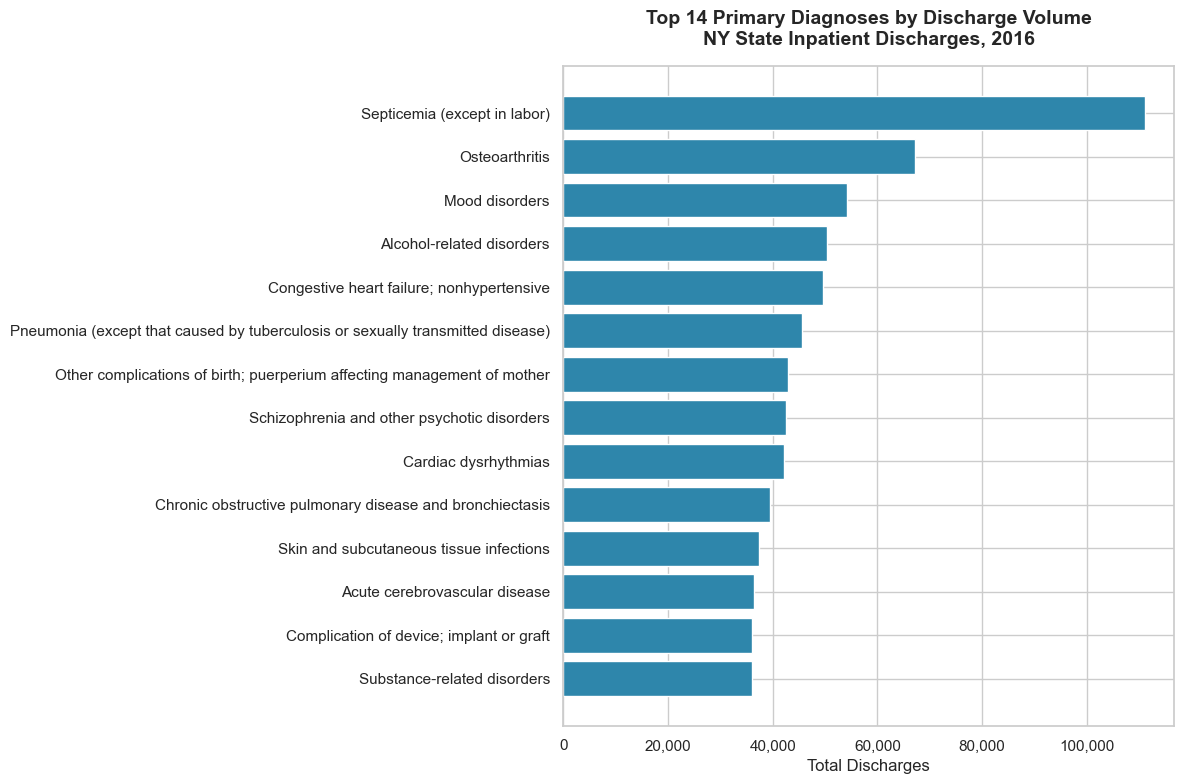

✓ Saved to visuals/01_top_diagnoses.png


In [13]:
fig, ax = plt.subplots(figsize=(12, 8))

# Exclude newborns — not clinically informative alongside adult diagnoses
plot_data = top_diagnoses[top_diagnoses["diagnosis"] != "Liveborn"].head(14)
plot_data = plot_data.sort_values("total_cases", ascending=True)

ax.barh(plot_data["diagnosis"], plot_data["total_cases"], color="#2E86AB")

ax.set_xlabel("Total Discharges")
ax.set_title("Top 14 Primary Diagnoses by Discharge Volume\nNY State Inpatient Discharges, 2016", 
             fontsize=14, fontweight="bold", pad=15)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("../visuals/01_top_diagnoses.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved to visuals/01_top_diagnoses.png")

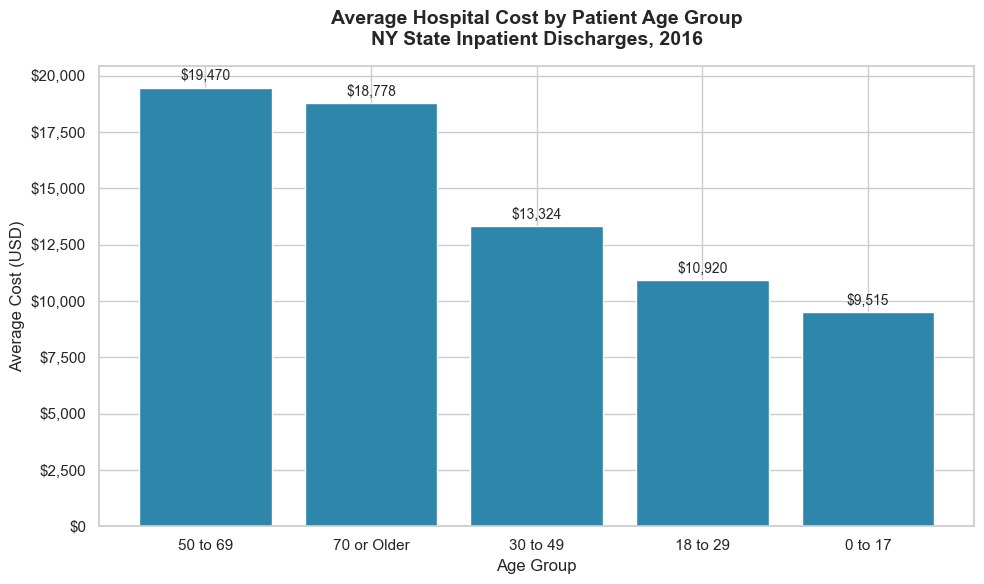

✓ Saved to visuals/02_cost_by_age.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

cost_by_age_sorted = cost_by_age.sort_values("avg_cost", ascending=False)

bars = ax.bar(cost_by_age_sorted["age_group"], cost_by_age_sorted["avg_cost"], color="#2E86AB")

# Label each bar with the dollar value
for bar, val in zip(bars, cost_by_age_sorted["avg_cost"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"${val:,.0f}", ha="center", va="bottom", fontsize=10)

ax.set_xlabel("Age Group")
ax.set_ylabel("Average Cost (USD)")
ax.set_title("Average Hospital Cost by Patient Age Group\nNY State Inpatient Discharges, 2016",
             fontsize=14, fontweight="bold", pad=15)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("../visuals/02_cost_by_age.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved to visuals/02_cost_by_age.png")

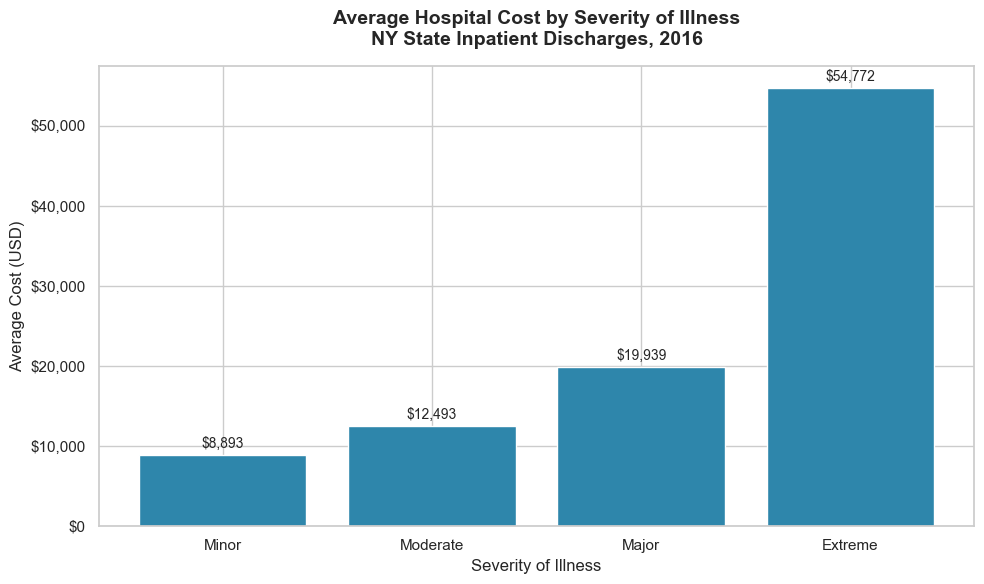

✓ Saved to visuals/03_cost_by_severity.png


In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

# Exclude severity code 0 — ungroupable cases, negligible volume
plot_data = cost_by_severity[cost_by_severity["severity_code"] != 0]

bars = ax.bar(plot_data["severity"], plot_data["avg_cost"], color="#2E86AB")

# Label each bar with the dollar value
for bar, val in zip(bars, plot_data["avg_cost"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f"${val:,.0f}", ha="center", va="bottom", fontsize=10)

ax.set_xlabel("Severity of Illness")
ax.set_ylabel("Average Cost (USD)")
ax.set_title("Average Hospital Cost by Severity of Illness\nNY State Inpatient Discharges, 2016",
             fontsize=14, fontweight="bold", pad=15)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("../visuals/03_cost_by_severity.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved to visuals/03_cost_by_severity.png")

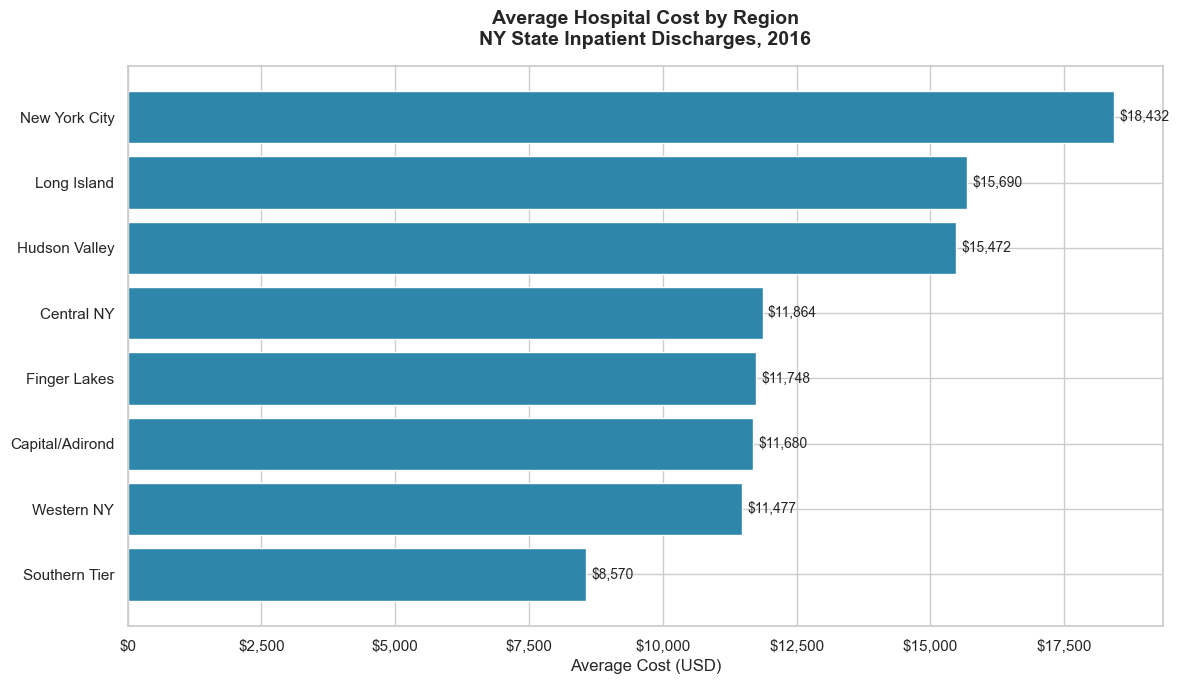

✓ Saved to visuals/04_cost_by_region.png


In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

# Drop null region record
plot_data = cost_by_region.dropna(subset=["health_service_area"])
plot_data = plot_data.sort_values("avg_cost", ascending=True)

bars = ax.barh(plot_data["health_service_area"], plot_data["avg_cost"], color="#2E86AB")

# Label each bar with the dollar value
for bar, val in zip(bars, plot_data["avg_cost"]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f"${val:,.0f}", va="center", fontsize=10)

ax.set_xlabel("Average Cost (USD)")
ax.set_title("Average Hospital Cost by Region\nNY State Inpatient Discharges, 2016",
             fontsize=14, fontweight="bold", pad=15)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("../visuals/04_cost_by_region.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved to visuals/04_cost_by_region.png")

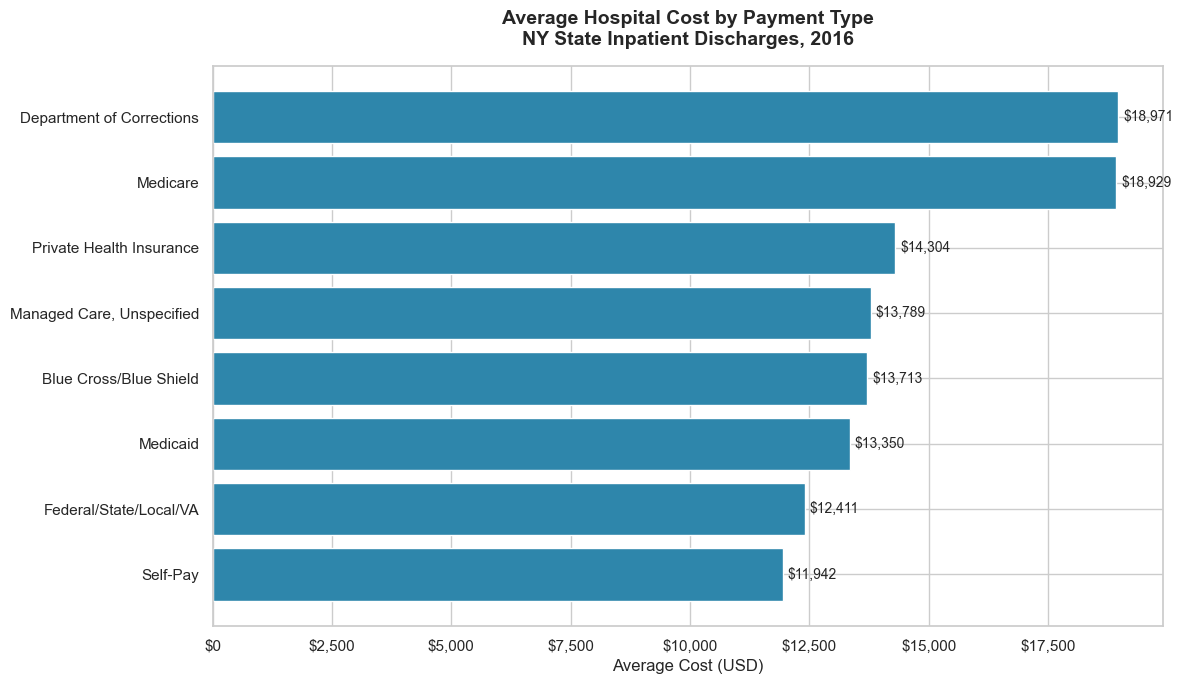

✓ Saved to visuals/05_cost_by_payment.png


In [18]:
fig, ax = plt.subplots(figsize=(12, 7))

# Filter to meaningful payment types — exclude Unknown and low-volume edge cases
plot_data = cost_by_payment[~cost_by_payment["payment_type"].isin(["Unknown", "Miscellaneous/Other"])]
plot_data = plot_data.sort_values("avg_cost", ascending=True)

bars = ax.barh(plot_data["payment_type"], plot_data["avg_cost"], color="#2E86AB")

# Label each bar with the dollar value
for bar, val in zip(bars, plot_data["avg_cost"]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f"${val:,.0f}", va="center", fontsize=10)

ax.set_xlabel("Average Cost (USD)")
ax.set_title("Average Hospital Cost by Payment Type\nNY State Inpatient Discharges, 2016",
             fontsize=14, fontweight="bold", pad=15)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("../visuals/05_cost_by_payment.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved to visuals/05_cost_by_payment.png")

## Key Findings

A summary of the most significant patterns identified across 2.3 million inpatient discharge 
records from New York State hospitals in 2016.

| # | Finding | Detail |
|---|---|---|
| 1 | **Severity is the strongest cost predictor** | Extreme severity cases average $54,772 — 6x the cost of Minor cases at $8,893. Length of stay follows the same pattern, rising from 3.1 to 15.2 days across severity levels. |
| 2 | **NYC costs 57% more than upstate regions** | New York City averages $18,432 per discharge vs $8,570 in the Southern Tier. Length of stay is consistent across regions, pointing to pricing and case mix as the drivers. |
| 3 | **Leukemia is the most expensive diagnosis** | At $80,944 average cost and 18.9 average days, leukemia far outpaces the next most expensive diagnosis (heart valve disorders at $57,552). |
| 4 | **Medicare dominates volume and cost** | Medicare covers 884,209 discharges at an average cost of $18,929 — the highest among standard payer types and nearly 42% higher than Medicaid at $13,350. |
| 5 | **Trauma admissions are the most resource intensive** | Despite accounting for only 6,629 cases, trauma admissions average the longest stays (6.4 days) and highest costs ($24,679) of any admission type. |
| 6 | **Middle-aged patients drive the highest costs** | The 50-69 age group averages $19,470 per discharge — double the cost of patients under 30 — and represents the largest patient volume in the dataset. |